In [15]:
import sys
import logging
import random

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# Importing necessary modules for data loading and transformation
from data_loader import DASDataLoader, fft
from siamese import set_seed, get_device, SimilarityDataset, SiameseClassifier

logging.basicConfig(level=logging.INFO)

In [16]:
decim_dict = {
    # The 'regular' label will be decimated by a factor of 50
    # 'regular': 50,
}

decim_dict = {
    # The 'regular' label will be decimated by a factor of 50
    # 'regular': 90,
    # 'fence': 90,
    # 'longboard': 90,
    # 'manipulation': 90,
    # 'openclose': 90,
    # 'running': 90,
    # 'walk': 90,
    # 'car': 90,
    # 'construction': 90,
}

# Initializing the DASDataLoader with dataset parameters
parser = DASDataLoader(
    '/nobackup/carda/datasets/DAS-dataset/data',  # Path to the dataset directory
    2048,  # Sample length
    transform=fft,  # Applying FFT as a preprocessing step
    fsize=8192,  # Window size for sliding window segmentation
    # Step size for the sliding window (overlap of 75% with fsize=8192)
    shift=2048,
    # Dictionary specifying the decimation factor for each label
    decimate=decim_dict,
)


In [17]:
# Parsing the dataset into features (x) and labels (y)
x, y = parser.parse_dataset()

# Output parsed dataset details
print(x, y)
print(f'The dataset contains {len(x)} elements')

INFO:data_loader:Parsing dataset for label [walk]...
INFO:data_loader:Parsing dataset for label [car]...
INFO:data_loader:Parsing dataset for label [longboard]...
INFO:data_loader:Parsing dataset for label [construction]...
INFO:data_loader:Parsing dataset for label [regular]...
INFO:data_loader:Parsing dataset for label [fence]...
INFO:data_loader:Parsing dataset for label [openclose]...
INFO:data_loader:Parsing dataset for label [running]...
INFO:data_loader:Parsing dataset for label [manipulation]...
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/construction/reconstruction1_2023-06-06T150714+0100.h5
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/walk/walking2_2023-04-17T122153+0100.h5
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/longboard/longboard_2023-04-17T123543+0100.h5
INFO:data_loader:Processing file: /nobackup/carda/datasets/DAS-dataset/data/car/auto2_2023-04-17T124510+0100.h5
INFO:data_

[[5.6094537 5.097933  4.700012  ... 4.093706  4.3315716 4.1064677]
 [5.5273185 5.331628  5.296272  ... 4.318819  3.751658  4.4795156]
 [4.66952   4.5801835 4.461422  ... 4.1655807 4.2454867 4.2480106]
 ...
 [6.2491736 6.4206333 6.8543096 ... 4.094826  3.808321  3.705519 ]
 [5.9568806 5.6151996 6.0756884 ... 3.258548  4.094016  4.209584 ]
 [4.4336452 4.881655  4.991021  ... 4.2888474 3.7518768 4.1855836]] [[0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
The dataset contains 324464 elements


In [18]:
full_mean = np.mean(x, axis=0, keepdims=True)
full_std = np.std(x, axis=0, keepdims=True) + 1e-8
x_normalized = (x - full_mean) / full_std
x_normalized.shape


(324464, 2048)

In [19]:
y.argmax(axis=1)
Y = y.argmax(axis=1)
Y.shape

(324464,)

In [20]:
# Model parameters - should match the training configuration
INPUT_DIM = 2048
EMBEDDING_DIM = 512
NETWORK = 'cnn'
CHECKPOINT_PATH = 'checkpoints/best_siamese_model_512_512_True_cnn.pth'

# Initialize the model
model = SiameseClassifier(input_dim=INPUT_DIM, embedding_dim=EMBEDDING_DIM, network=NETWORK)

# Load the checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=model.device)
model.embedding_network.load_state_dict(checkpoint['embedding_network_state_dict'])
model.similarity_head.load_state_dict(checkpoint['similarity_head_state_dict'])

# Set to evaluation mode
model.embedding_network.eval()
model.similarity_head.eval()

print(f"Model loaded from {CHECKPOINT_PATH}")

Using CUDA: NVIDIA GeForce RTX 2080 Ti
Model loaded from checkpoints/best_siamese_model_512_512_True_cnn.pth


In [21]:
def evaluate_n_way_k_shot(model, x, y, n_way=5, k_shot=1, n_trials=100, seed=42):
    """
    Evaluates N-way K-shot classification accuracy.
    
    Args:
        model: SiameseClassifier instance
        x (np.ndarray): Feature matrix of shape (N_samples, feature_dim)
        y (np.ndarray): Label vector of shape (N_samples,)
        n_way (int): Number of classes to sample per episode
        k_shot (int): Number of support samples per class
        n_trials (int): Number of episodes to evaluate
        seed (int): Random seed for reproducibility
    
    Returns:
        accuracy (float): Overall accuracy
        all_predictions (list): Predicted class indices
        all_targets (list): True class indices
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    unique_classes = np.unique(y)
    
    # Ensure we have enough classes for n_way
    if n_way > len(unique_classes):
        print(f"Warning: n_way ({n_way}) > number of classes ({len(unique_classes)}). Using {len(unique_classes)} classes.")
        n_way = len(unique_classes)
    
    # Build class indices
    class_indices = {c: np.where(y == c)[0] for c in unique_classes}
    
    # Filter classes that have at least k_shot + 1 samples (k for support, 1 for query)
    valid_classes = [c for c in unique_classes if len(class_indices[c]) >= k_shot + 1]
    if len(valid_classes) < n_way:
        print(f"Warning: Only {len(valid_classes)} classes have enough samples for {k_shot}-shot. Adjusting n_way.")
        n_way = len(valid_classes)
    
    correct = 0
    total = 0
    all_predictions = []
    all_targets = []
    
    model.embedding_network.eval()
    model.similarity_head.eval()
    
    for trial in range(n_trials):
        # Sample n_way classes for this episode
        episode_classes = np.random.choice(valid_classes, n_way, replace=False)
        
        # For each class, sample k_shot support samples and 1 query sample
        support_samples = []
        support_labels = []
        
        for cls_idx, cls in enumerate(episode_classes):
            available_indices = class_indices[cls].copy()
            np.random.shuffle(available_indices)
            
            # Take k_shot samples for support set
            support_indices = available_indices[:k_shot]
            for idx in support_indices:
                support_samples.append(x[idx])
                support_labels.append(cls_idx)  # Use local class index (0 to n_way-1)
        
        # Convert to tensors
        support_samples = torch.tensor(np.array(support_samples), dtype=torch.float32).to(model.device)
        
        # Select a random query class and sample
        query_cls_idx = np.random.randint(0, n_way)
        query_cls = episode_classes[query_cls_idx]
        
        # Get indices not used in support set
        available_query_indices = [idx for idx in class_indices[query_cls] 
                                   if idx not in class_indices[query_cls][:k_shot]]
        if len(available_query_indices) == 0:
            # Fallback: use any sample from the class not in support
            all_cls_indices = list(class_indices[query_cls])
            support_used = list(class_indices[query_cls][:k_shot])
            available_query_indices = [i for i in all_cls_indices if i not in support_used]
            if len(available_query_indices) == 0:
                continue  # Skip this trial if no query available
        
        query_idx = np.random.choice(available_query_indices)
        query_sample = torch.tensor(x[query_idx:query_idx+1], dtype=torch.float32).to(model.device)
        
        # Compute similarity between query and all support samples
        with torch.no_grad():
            query_expanded = query_sample.expand(support_samples.shape[0], -1)
            similarities = model.forward(query_expanded, support_samples)  # Shape: [n_way * k_shot, 1]
            similarities = similarities.view(-1)  # Shape: [n_way * k_shot]
            
            # Average similarities per class (for k > 1)
            class_similarities = []
            for cls_idx in range(n_way):
                start_idx = cls_idx * k_shot
                end_idx = start_idx + k_shot
                cls_sim = similarities[start_idx:end_idx].mean().item()
                class_similarities.append(cls_sim)
            
            # Predict the class with highest similarity
            pred_cls_idx = np.argmax(class_similarities)
        
        if pred_cls_idx == query_cls_idx:
            correct += 1
        total += 1
        
        all_predictions.append(pred_cls_idx)
        all_targets.append(query_cls_idx)
    
    accuracy = correct / total if total > 0 else 0.0
    return accuracy, all_predictions, all_targets


In [22]:
# Split dataset into train/test for proper evaluation
# We'll evaluate on a held-out test set
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    x_normalized, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print(f"Train samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Classes: {parser.encoder.classes_}")


Train samples: 259571
Test samples: 64893
Classes: ['car' 'construction' 'fence' 'longboard' 'manipulation' 'openclose'
 'regular' 'running' 'walk']


In [28]:
# Run N-way K-shot evaluation with various configurations
N_TRIALS = 10000  # Number of episodes for robust evaluation

# Define evaluation configurations: (n_way, k_shot)
configs = [
    (5, 1),   # 5-way 1-shot
    (5, 5),   # 5-way 5-shot
    (9, 1),   # 9-way 1-shot (all classes)
    (9, 5),   # 9-way 5-shot (all classes)
]

results = {}

print("=" * 60)
print("N-way K-shot Evaluation Results")
print("=" * 60)

for n_way, k_shot in configs:
    print(f"\nEvaluating {n_way}-way {k_shot}-shot...")
    
    accuracy, predictions, targets = evaluate_n_way_k_shot(
        model, 
        X_test, 
        Y_test,
        n_way=n_way,
        k_shot=k_shot,
        n_trials=N_TRIALS,
        seed=42
    )
    
    results[(n_way, k_shot)] = {
        'accuracy': accuracy,
        'predictions': predictions,
        'targets': targets
    }
    
    print(f"{n_way}-way {k_shot}-shot Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n" + "=" * 60)


N-way K-shot Evaluation Results

Evaluating 5-way 1-shot...
5-way 1-shot Accuracy: 0.6845 (68.45%)

Evaluating 5-way 5-shot...
5-way 5-shot Accuracy: 0.7577 (75.77%)

Evaluating 9-way 1-shot...
9-way 1-shot Accuracy: 0.5687 (56.87%)

Evaluating 9-way 5-shot...


KeyboardInterrupt: 

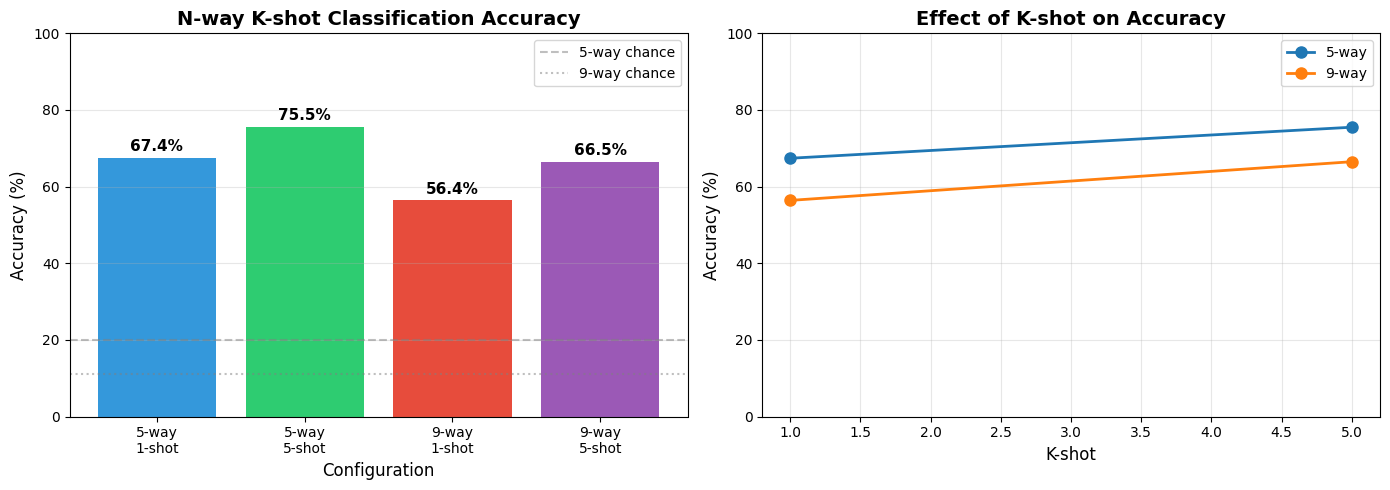


Plot saved to checkpoints/n_way_k_shot_results.png


In [24]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart of accuracies
config_labels = [f"{n}-way\n{k}-shot" for n, k in configs]
accuracies = [results[(n, k)]['accuracy'] * 100 for n, k in configs]

bars = axes[0].bar(config_labels, accuracies, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_xlabel('Configuration', fontsize=12)
axes[0].set_title('N-way K-shot Classification Accuracy', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].axhline(y=100/5, color='gray', linestyle='--', alpha=0.5, label='5-way chance')
axes[0].axhline(y=100/9, color='gray', linestyle=':', alpha=0.5, label='9-way chance')
axes[0].legend(loc='upper right')

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{acc:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Effect of K-shot on accuracy
n_ways = sorted(set([n for n, k in configs]))
for n_way in n_ways:
    k_shots = sorted([k for n, k in configs if n == n_way])
    accs = [results[(n_way, k)]['accuracy'] * 100 for k in k_shots]
    axes[1].plot(k_shots, accs, 'o-', linewidth=2, markersize=8, label=f'{n_way}-way')

axes[1].set_xlabel('K-shot', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Effect of K-shot on Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('checkpoints/n_way_k_shot_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to checkpoints/n_way_k_shot_results.png")


In [25]:
# Summary table
import pandas as pd

summary_data = []
for (n_way, k_shot), res in results.items():
    chance = 100.0 / n_way
    acc = res['accuracy'] * 100
    summary_data.append({
        'N-way': n_way,
        'K-shot': k_shot,
        'Accuracy (%)': f"{acc:.2f}",
        'Chance Level (%)': f"{chance:.2f}",
        'Above Chance': f"+{acc - chance:.2f}%"
    })

summary_df = pd.DataFrame(summary_data)
print("\nSummary Table:")
print(summary_df.to_string(index=False))



Summary Table:
 N-way  K-shot Accuracy (%) Chance Level (%) Above Chance
     5       1        67.40            20.00      +47.40%
     5       5        75.50            20.00      +55.50%
     9       1        56.40            11.11      +45.29%
     9       5        66.50            11.11      +55.39%


In [26]:
def evaluate_n_way_k_shot_with_ci(model, x, y, n_way=5, k_shot=1, n_trials=1000, n_bootstrap=5, seed=42):
    """
    Evaluates N-way K-shot with confidence intervals using bootstrap.
    
    Returns:
        mean_accuracy, std_accuracy, (lower_ci, upper_ci)
    """
    accuracies = []
    
    for i in range(n_bootstrap):
        acc, _, _ = evaluate_n_way_k_shot(
            model, x, y, 
            n_way=n_way, 
            k_shot=k_shot, 
            n_trials=n_trials, 
            seed=seed + i
        )
        accuracies.append(acc)
    
    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)
    ci_lower = np.percentile(accuracies, 2.5)
    ci_upper = np.percentile(accuracies, 97.5)
    
    return mean_acc, std_acc, (ci_lower, ci_upper)

# Run evaluation with confidence intervals
print("=" * 70)
print("N-way K-shot Evaluation with 95% Confidence Intervals")
print("=" * 70)

ci_results = {}
for n_way, k_shot in configs:
    print(f"\nEvaluating {n_way}-way {k_shot}-shot (5 bootstrap runs)...")
    
    mean_acc, std_acc, (ci_lower, ci_upper) = evaluate_n_way_k_shot_with_ci(
        model, X_test, Y_test,
        n_way=n_way,
        k_shot=k_shot,
        n_trials=200,  # Fewer trials per bootstrap for speed
        n_bootstrap=5,
        seed=42
    )
    
    ci_results[(n_way, k_shot)] = {
        'mean': mean_acc,
        'std': std_acc,
        'ci': (ci_lower, ci_upper)
    }
    
    print(f"{n_way}-way {k_shot}-shot: {mean_acc*100:.2f}% ± {std_acc*100:.2f}% (95% CI: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%])")

print("\n" + "=" * 70)


N-way K-shot Evaluation with 95% Confidence Intervals

Evaluating 5-way 1-shot (5 bootstrap runs)...
5-way 1-shot: 66.80% ± 1.36% (95% CI: [65.05%, 68.45%])

Evaluating 5-way 5-shot (5 bootstrap runs)...
5-way 5-shot: 74.80% ± 3.59% (95% CI: [69.50%, 79.65%])

Evaluating 9-way 1-shot (5 bootstrap runs)...
9-way 1-shot: 58.70% ± 2.38% (95% CI: [56.05%, 62.25%])

Evaluating 9-way 5-shot (5 bootstrap runs)...
9-way 5-shot: 65.40% ± 1.66% (95% CI: [63.15%, 67.45%])



In [27]:
import pickle

# Save all results
evaluation_results = {
    'results': results,
    'ci_results': ci_results,
    'configs': configs,
    'n_trials': N_TRIALS,
    'model_checkpoint': CHECKPOINT_PATH,
    'class_names': list(parser.encoder.classes_),
}

with open('checkpoints/n_way_k_shot_evaluation.pkl', 'wb') as f:
    pickle.dump(evaluation_results, f)

print("Results saved to checkpoints/n_way_k_shot_evaluation.pkl")


Results saved to checkpoints/n_way_k_shot_evaluation.pkl


In [29]:
def evaluate_open_set_recognition(model, x, y, k_shot=5, n_trials=100, similarity_threshold=0.5, seed=42):
    """
    Evaluates Open Set Recognition (OSR) / Novelty Detection capability.
    
    This tests the model's ability to detect samples from unknown/novel classes
    that were not present in the support set.
    
    Terminology in AI Research:
    - Open Set Recognition (OSR): Rejecting samples from unknown classes
    - Out-of-Distribution (OOD) Detection: Detecting samples outside training distribution  
    - Novelty Detection: Identifying new/unseen patterns
    - Few-Shot Open-Set Recognition: OSR in few-shot learning context
    
    Methodology:
    1. Hold out one class as "unknown" (novel class)
    2. Use K samples from remaining "known" classes as support set
    3. Query with samples from both known and unknown classes
    4. Model should have HIGH similarity for known class queries
    5. Model should have LOW similarity for unknown class queries
    
    Args:
        model: SiameseClassifier instance
        x: Feature matrix
        y: Label vector
        k_shot: Number of support samples per known class
        n_trials: Number of evaluation episodes
        similarity_threshold: Threshold to classify as "known" vs "unknown"
        seed: Random seed
    
    Returns:
        Dictionary with detailed metrics
    """
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    unique_classes = np.unique(y)
    n_classes = len(unique_classes)
    class_indices = {c: np.where(y == c)[0] for c in unique_classes}
    
    # Metrics
    known_correct = 0  # Known samples correctly identified as known
    known_total = 0
    unknown_correct = 0  # Unknown samples correctly identified as unknown
    unknown_total = 0
    
    all_known_similarities = []
    all_unknown_similarities = []
    
    per_class_as_unknown = {c: {'correct': 0, 'total': 0, 'similarities': []} for c in unique_classes}
    
    model.embedding_network.eval()
    model.similarity_head.eval()
    
    for trial in range(n_trials):
        # Select one class to be "unknown" (novel)
        unknown_class = np.random.choice(unique_classes)
        known_classes = [c for c in unique_classes if c != unknown_class]
        
        # Build support set from known classes only
        support_samples = []
        support_class_ids = []
        
        for cls_idx, cls in enumerate(known_classes):
            available = class_indices[cls].copy()
            np.random.shuffle(available)
            if len(available) < k_shot + 1:
                continue
            for idx in available[:k_shot]:
                support_samples.append(x[idx])
                support_class_ids.append(cls_idx)
        
        if len(support_samples) == 0:
            continue
            
        support_tensor = torch.tensor(np.array(support_samples), dtype=torch.float32).to(model.device)
        
        # Test 1: Query with a KNOWN class sample (should match)
        query_known_class = np.random.choice(known_classes)
        known_cls_idx = known_classes.index(query_known_class)
        available_known = [i for i in class_indices[query_known_class] if i not in class_indices[query_known_class][:k_shot]]
        if len(available_known) > 0:
            query_idx = np.random.choice(available_known)
            query_sample = torch.tensor(x[query_idx:query_idx+1], dtype=torch.float32).to(model.device)
            
            with torch.no_grad():
                query_expanded = query_sample.expand(support_tensor.shape[0], -1)
                similarities = model.forward(query_expanded, support_tensor).view(-1)
                max_similarity = similarities.max().item()
                
            all_known_similarities.append(max_similarity)
            if max_similarity >= similarity_threshold:
                known_correct += 1
            known_total += 1
        
        # Test 2: Query with an UNKNOWN class sample (should NOT match)
        available_unknown = list(class_indices[unknown_class])
        if len(available_unknown) > 0:
            query_idx = np.random.choice(available_unknown)
            query_sample = torch.tensor(x[query_idx:query_idx+1], dtype=torch.float32).to(model.device)
            
            with torch.no_grad():
                query_expanded = query_sample.expand(support_tensor.shape[0], -1)
                similarities = model.forward(query_expanded, support_tensor).view(-1)
                max_similarity = similarities.max().item()
            
            all_unknown_similarities.append(max_similarity)
            per_class_as_unknown[unknown_class]['similarities'].append(max_similarity)
            per_class_as_unknown[unknown_class]['total'] += 1
            
            if max_similarity < similarity_threshold:
                unknown_correct += 1
                per_class_as_unknown[unknown_class]['correct'] += 1
            unknown_total += 1
    
    # Calculate metrics
    known_accuracy = known_correct / known_total if known_total > 0 else 0
    unknown_accuracy = unknown_correct / unknown_total if unknown_total > 0 else 0
    
    # Balanced accuracy (average of known and unknown accuracies)
    balanced_accuracy = (known_accuracy + unknown_accuracy) / 2
    
    # AUROC calculation
    from sklearn.metrics import roc_auc_score, roc_curve
    
    y_true = [1] * len(all_known_similarities) + [0] * len(all_unknown_similarities)
    y_scores = all_known_similarities + all_unknown_similarities
    
    auroc = roc_auc_score(y_true, y_scores) if len(set(y_true)) > 1 else 0.5
    
    results = {
        'known_accuracy': known_accuracy,
        'unknown_accuracy': unknown_accuracy,
        'balanced_accuracy': balanced_accuracy,
        'auroc': auroc,
        'known_similarities': all_known_similarities,
        'unknown_similarities': all_unknown_similarities,
        'per_class_as_unknown': per_class_as_unknown,
        'threshold': similarity_threshold,
        'known_total': known_total,
        'unknown_total': unknown_total,
    }
    
    return results


# Configuration
N_OSR_TRIALS = 500  # Number of test episodes
K_SHOT_OSR = 5      # Support samples per known class
THRESHOLD = 0.5     # Similarity threshold for known vs unknown

print("=" * 70)
print("Open Set Recognition / Novelty Detection Evaluation")
print("=" * 70)
print(f"\nThis evaluates the model's ability to detect samples from NOVEL classes")
print(f"that are not present in the support set (Out-of-Distribution detection).")
print(f"\nTerminology: Open Set Recognition (OSR), OOD Detection, Novelty Detection")
print("=" * 70)

osr_results = evaluate_open_set_recognition(
    model, X_test, Y_test,
    k_shot=K_SHOT_OSR,
    n_trials=N_OSR_TRIALS,
    similarity_threshold=THRESHOLD,
    seed=42
)

print(f"\nResults with threshold = {THRESHOLD}:")
print(f"  Known Class Accuracy:   {osr_results['known_accuracy']*100:.2f}% (correctly identified as known)")
print(f"  Unknown Class Accuracy: {osr_results['unknown_accuracy']*100:.2f}% (correctly rejected as unknown)")
print(f"  Balanced Accuracy:      {osr_results['balanced_accuracy']*100:.2f}%")
print(f"  AUROC:                  {osr_results['auroc']:.4f}")
print(f"\n  Avg similarity (known):   {np.mean(osr_results['known_similarities']):.4f} ± {np.std(osr_results['known_similarities']):.4f}")
print(f"  Avg similarity (unknown): {np.mean(osr_results['unknown_similarities']):.4f} ± {np.std(osr_results['unknown_similarities']):.4f}")


Open Set Recognition / Novelty Detection Evaluation

This evaluates the model's ability to detect samples from NOVEL classes
that are not present in the support set (Out-of-Distribution detection).

Terminology: Open Set Recognition (OSR), OOD Detection, Novelty Detection

Results with threshold = 0.5:
  Known Class Accuracy:   100.00% (correctly identified as known)
  Unknown Class Accuracy: 9.00% (correctly rejected as unknown)
  Balanced Accuracy:      54.50%
  AUROC:                  0.7041

  Avg similarity (known):   0.9188 ± 0.1043
  Avg similarity (unknown): 0.8031 ± 0.2213


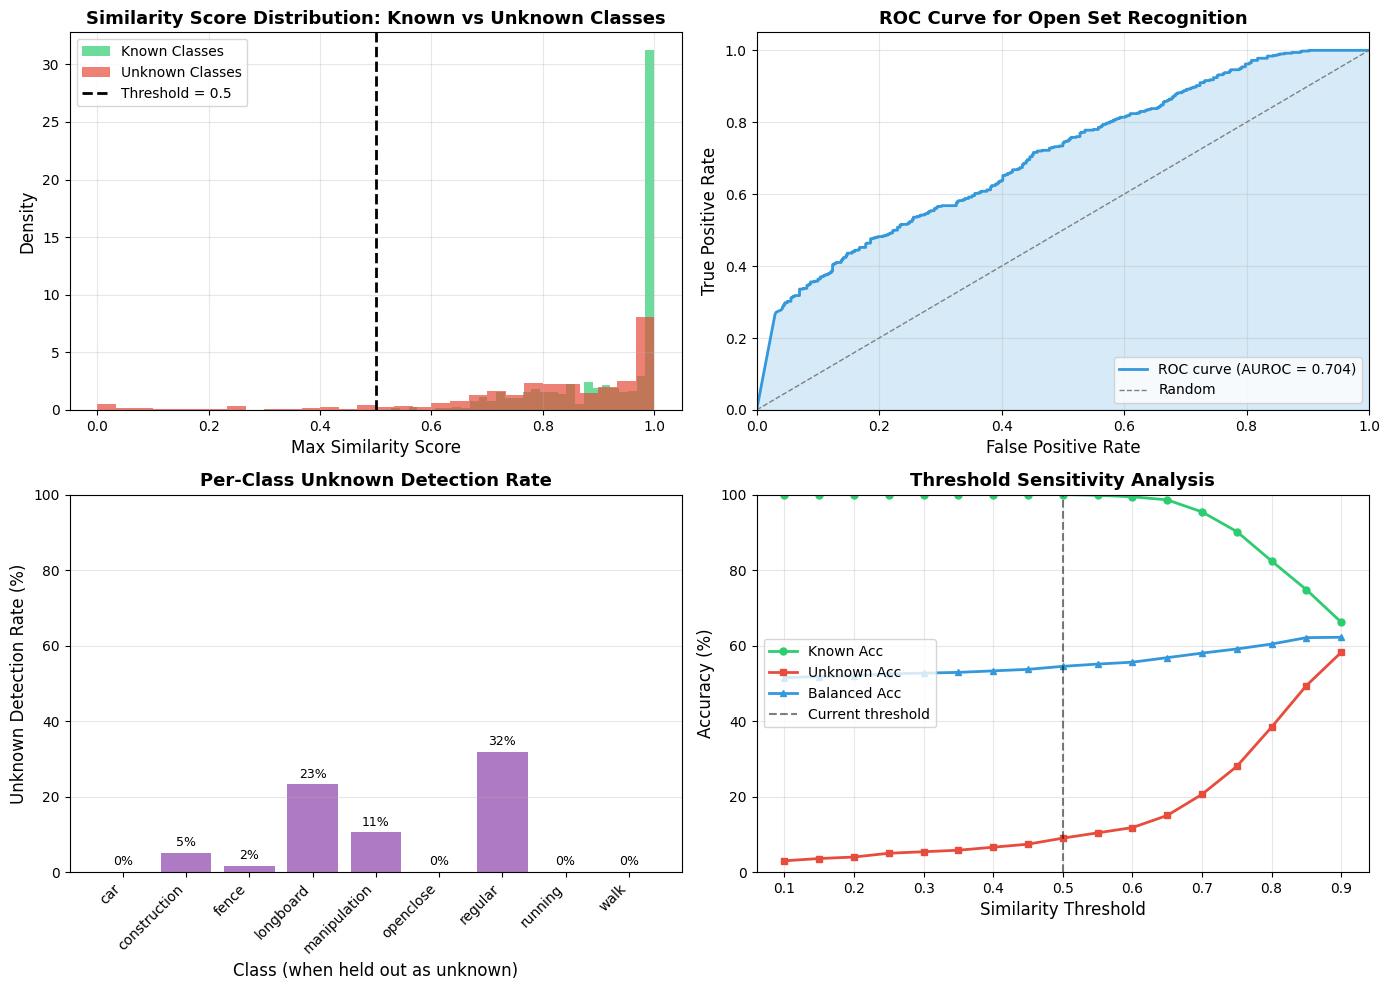


Optimal threshold for balanced accuracy: 0.90
  - Known Accuracy at optimal: 66.2%
  - Unknown Accuracy at optimal: 58.2%
  - Balanced Accuracy at optimal: 62.2%


In [30]:
# Visualization of Open Set Recognition results
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Similarity distribution histogram
ax1 = axes[0, 0]
ax1.hist(osr_results['known_similarities'], bins=30, alpha=0.7, label='Known Classes', color='#2ecc71', density=True)
ax1.hist(osr_results['unknown_similarities'], bins=30, alpha=0.7, label='Unknown Classes', color='#e74c3c', density=True)
ax1.axvline(x=THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Threshold = {THRESHOLD}')
ax1.set_xlabel('Max Similarity Score', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Similarity Score Distribution: Known vs Unknown Classes', fontsize=13, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: ROC Curve
ax2 = axes[0, 1]
y_true = [1] * len(osr_results['known_similarities']) + [0] * len(osr_results['unknown_similarities'])
y_scores = osr_results['known_similarities'] + osr_results['unknown_similarities']
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='#3498db', linewidth=2, label=f'ROC curve (AUROC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1, label='Random')
ax2.fill_between(fpr, tpr, alpha=0.2, color='#3498db')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('ROC Curve for Open Set Recognition', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])

# Plot 3: Per-class performance as unknown
ax3 = axes[1, 0]
class_names = list(parser.encoder.classes_)
per_class_acc = []
per_class_mean_sim = []
for cls_id in sorted(osr_results['per_class_as_unknown'].keys()):
    data = osr_results['per_class_as_unknown'][cls_id]
    acc = data['correct'] / data['total'] if data['total'] > 0 else 0
    mean_sim = np.mean(data['similarities']) if data['similarities'] else 0
    per_class_acc.append(acc * 100)
    per_class_mean_sim.append(mean_sim)

x_pos = np.arange(len(class_names))
bars = ax3.bar(x_pos, per_class_acc, color='#9b59b6', alpha=0.8)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(class_names, rotation=45, ha='right')
ax3.set_ylabel('Unknown Detection Rate (%)', fontsize=12)
ax3.set_xlabel('Class (when held out as unknown)', fontsize=12)
ax3.set_title('Per-Class Unknown Detection Rate', fontsize=13, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim(0, 100)

for bar, acc in zip(bars, per_class_acc):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.0f}%', ha='center', va='bottom', fontsize=9)

# Plot 4: Threshold sensitivity analysis
ax4 = axes[1, 1]
thresholds_to_test = np.linspace(0.1, 0.9, 17)
known_accs = []
unknown_accs = []
balanced_accs = []

for thresh in thresholds_to_test:
    known_acc = sum(1 for s in osr_results['known_similarities'] if s >= thresh) / len(osr_results['known_similarities'])
    unknown_acc = sum(1 for s in osr_results['unknown_similarities'] if s < thresh) / len(osr_results['unknown_similarities'])
    known_accs.append(known_acc * 100)
    unknown_accs.append(unknown_acc * 100)
    balanced_accs.append((known_acc + unknown_acc) / 2 * 100)

ax4.plot(thresholds_to_test, known_accs, 'o-', color='#2ecc71', linewidth=2, label='Known Acc', markersize=5)
ax4.plot(thresholds_to_test, unknown_accs, 's-', color='#e74c3c', linewidth=2, label='Unknown Acc', markersize=5)
ax4.plot(thresholds_to_test, balanced_accs, '^-', color='#3498db', linewidth=2, label='Balanced Acc', markersize=5)
ax4.axvline(x=THRESHOLD, color='black', linestyle='--', alpha=0.5, label=f'Current threshold')
ax4.set_xlabel('Similarity Threshold', fontsize=12)
ax4.set_ylabel('Accuracy (%)', fontsize=12)
ax4.set_title('Threshold Sensitivity Analysis', fontsize=13, fontweight='bold')
ax4.legend(loc='center left')
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('checkpoints/open_set_recognition_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Find optimal threshold
optimal_idx = np.argmax(balanced_accs)
optimal_threshold = thresholds_to_test[optimal_idx]
print(f"\nOptimal threshold for balanced accuracy: {optimal_threshold:.2f}")
print(f"  - Known Accuracy at optimal: {known_accs[optimal_idx]:.1f}%")
print(f"  - Unknown Accuracy at optimal: {unknown_accs[optimal_idx]:.1f}%")
print(f"  - Balanced Accuracy at optimal: {balanced_accs[optimal_idx]:.1f}%")


In [31]:
# Summary table for Open Set Recognition per class
print("\n" + "=" * 70)
print("Per-Class Open Set Recognition Summary")
print("=" * 70)

osr_summary = []
for cls_id in sorted(osr_results['per_class_as_unknown'].keys()):
    data = osr_results['per_class_as_unknown'][cls_id]
    cls_name = class_names[cls_id]
    acc = data['correct'] / data['total'] * 100 if data['total'] > 0 else 0
    mean_sim = np.mean(data['similarities']) if data['similarities'] else 0
    std_sim = np.std(data['similarities']) if data['similarities'] else 0
    osr_summary.append({
        'Class': cls_name,
        'Detection Rate (%)': f"{acc:.1f}",
        'Mean Similarity': f"{mean_sim:.3f}",
        'Std Similarity': f"{std_sim:.3f}",
        'N Trials': data['total']
    })

osr_df = pd.DataFrame(osr_summary)
print(osr_df.to_string(index=False))

# Save OSR results
osr_save_data = {
    'osr_results': osr_results,
    'config': {
        'n_trials': N_OSR_TRIALS,
        'k_shot': K_SHOT_OSR,
        'threshold': THRESHOLD,
        'optimal_threshold': optimal_threshold,
    },
    'class_names': class_names,
}

with open('checkpoints/open_set_recognition_evaluation.pkl', 'wb') as f:
    pickle.dump(osr_save_data, f)

print(f"\nOSR results saved to checkpoints/open_set_recognition_evaluation.pkl")



Per-Class Open Set Recognition Summary
       Class Detection Rate (%) Mean Similarity Std Similarity  N Trials
         car                0.0           0.839          0.096        50
construction                5.0           0.837          0.151        60
       fence                1.7           0.794          0.123        59
   longboard               23.2           0.692          0.268        56
manipulation               10.5           0.814          0.212        57
   openclose                0.0           0.853          0.126        54
     regular               31.9           0.701          0.402        69
     running                0.0           0.895          0.110        48
        walk                0.0           0.852          0.089        47

OSR results saved to checkpoints/open_set_recognition_evaluation.pkl
